In [9]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Porównania:
# regresja logistyczna
# SVM
# Random Forest

df = pd.read_csv('wydarzenia2.csv',sep=';')
df

,Wydarzenie,Naglowek
0,BIZNES,Indonezyjski samolot zniknął z radarów. Wiózł ...
1,BIZNES,Najbogatszy człowiek świata domaga się wielkie...
2,BIZNES,Zarząd Dino nie pojawił się na spotkaniu ze zw...
3,BIZNES,Paramount zabiega o poparcie Europy. Zaostrza ...
4,BIZNES,Dwaj giganci połączą siły. BBC i YouTube mają ...
...,...,...
1271,BRAK_ZDARZENIA,Nowy dron dostawczy przeszedł pomyślnie testy ...
1272,BRAK_ZDARZENIA,Historia pierwszych polskich sukcesów na letni...
1273,BRAK_ZDARZENIA,Rozwój wirtualnych asystentów: czy zastąpią na...
1274,BRAK_ZDARZENIA,Polscy motocykliści ruszyli na wyprawę przez c...


In [10]:
df.groupby('Wydarzenie').count()

,Naglowek
Wydarzenie,
BIZNES,336
BRAK_ZDARZENIA,260
POLITYKA,380
WYPADEK,300


--- ROZPOCZĘCIE EKSPERYMENTÓW ---

Wyniki dla: Logistic Regression
                precision    recall  f1-score   support

        BIZNES       0.68      0.88      0.77        68
BRAK_ZDARZENIA       0.92      0.46      0.62        52
      POLITYKA       0.84      0.95      0.89        76
       WYPADEK       0.93      0.87      0.90        60

      accuracy                           0.81       256
     macro avg       0.84      0.79      0.79       256
  weighted avg       0.83      0.81      0.80       256

------------------------------


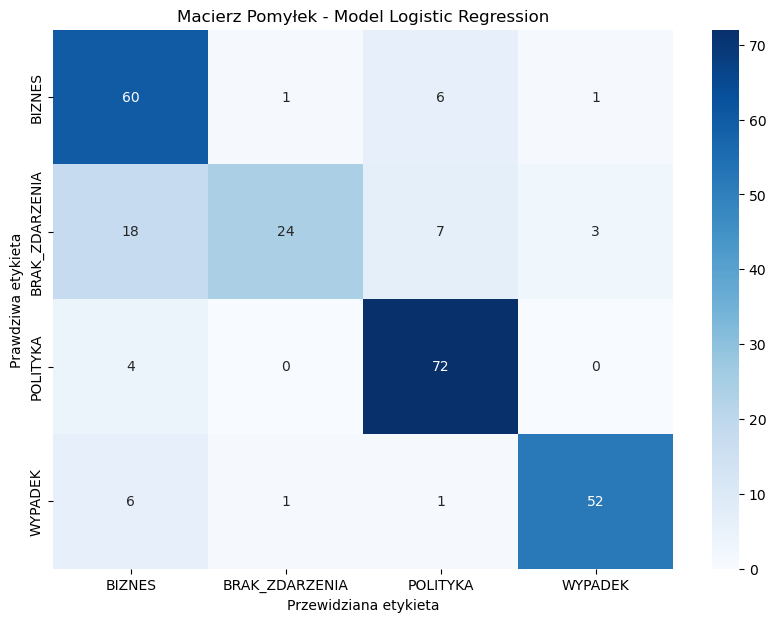

Wyniki dla: Linear SVM
                precision    recall  f1-score   support

        BIZNES       0.71      0.87      0.78        68
BRAK_ZDARZENIA       0.83      0.58      0.68        52
      POLITYKA       0.86      0.89      0.88        76
       WYPADEK       0.91      0.88      0.90        60

      accuracy                           0.82       256
     macro avg       0.83      0.81      0.81       256
  weighted avg       0.83      0.82      0.82       256

------------------------------


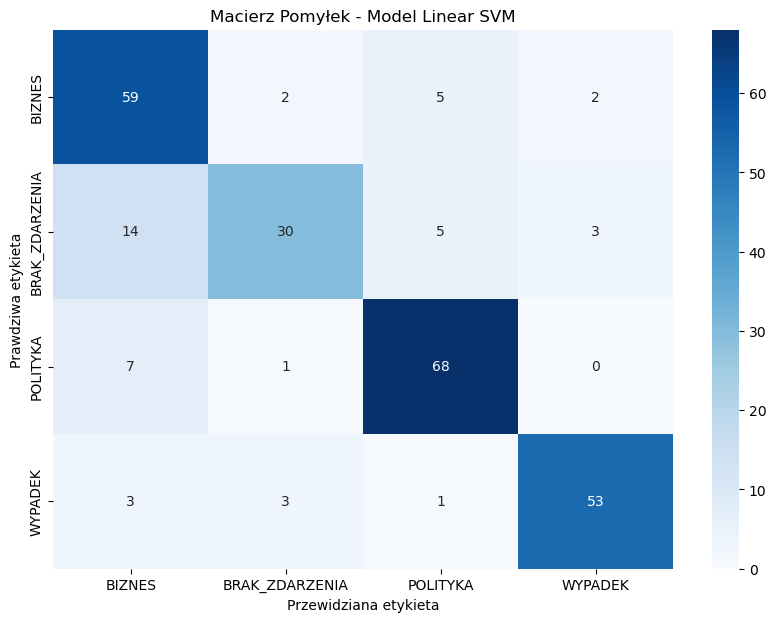

Wyniki dla: Random Forest
                precision    recall  f1-score   support

        BIZNES       0.51      0.75      0.61        68
BRAK_ZDARZENIA       0.43      0.35      0.38        52
      POLITYKA       0.91      0.68      0.78        76
       WYPADEK       0.81      0.77      0.79        60

      accuracy                           0.65       256
     macro avg       0.66      0.64      0.64       256
  weighted avg       0.68      0.65      0.66       256

------------------------------


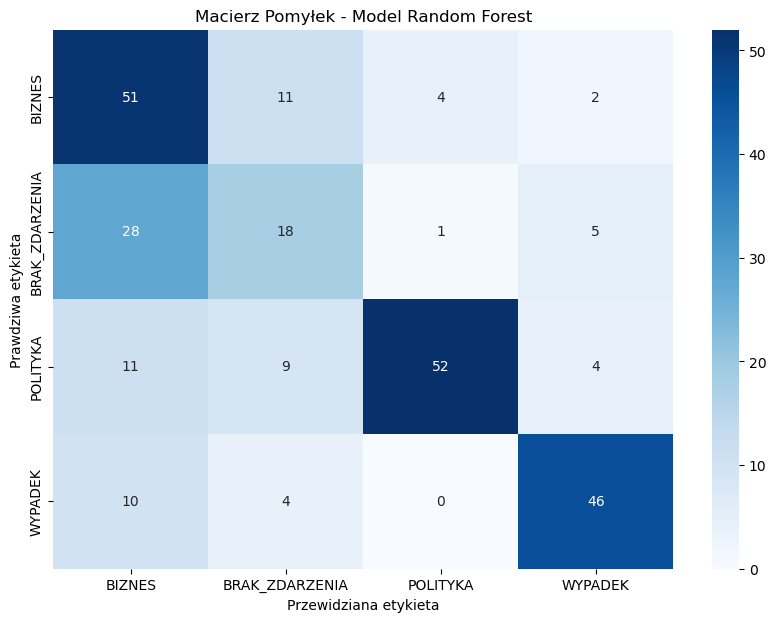


RANKING MODELI:
                 Model  F1-Score
1           Linear SVM  0.817093
0  Logistic Regression  0.803345
2        Random Forest  0.655503


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Naglowek'], df['Wydarzenie'], test_size=0.2, random_state=42, stratify=df['Wydarzenie']
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": SVC(kernel='linear', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

results = []
print("--- ROZPOCZĘCIE EKSPERYMENTÓW ---\n")

for name, model in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2))), # unigramy i bigramy
        ('clf', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({"Model": name, "F1-Score": f1})
    
    print(f"Wyniki dla: {name}")
    print(classification_report(y_test, y_pred))
    print("-" * 30)
    labels = sorted(df['Wydarzenie'].unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

    plt.xlabel('Przewidziana etykieta')
    plt.ylabel('Prawdziwa etykieta')
    plt.title(f'Macierz Pomyłek - Model {name}')
    plt.show()

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("\nRANKING MODELI:")
print(results_df)

# Rezultat Model SVM najlepszy 84% prawidłowej klasyfikacji

In [12]:
import spacy

nlp = spacy.load("pl_core_news_lg")

def extract_info(text):
    doc = nlp(text)
    result = {"KTO": None, "CO": None, "TRIGGER": None}
    
    for token in doc:
        if token.pos_ == "VERB":
            result["TRIGGER"] = token.lemma_
            
            for child in token.children:
                if child.dep_ == "nsubj":
                    result["KTO"] = child.text
                if child.dep_ in ["obj", "obl"]:
                    result["CO"] = child.text
    return result

print(extract_info("Napastnik pobił ochroniarza przed klubem"))
# Wynik: {'KTO': 'Napastnik', 'CO': 'ochroniarza', 'TRIGGER': 'pobić'}


{'KTO': 'Napastnik', 'CO': 'klubem', 'TRIGGER': 'pobić'}


In [ ]:
import pandas as pd

# Dane do zbioru testowego (Gold Standard)
data = [
    # --- BIZNES (Wybrane z Twojego pliku i uzupełnione) ---
    ["Orlen zbuduje pierwszy przyzakładowy magazyn energii.", "BIZNES", "zbudować", "Orlen", "pierwszy przyzakładowy magazyn energii"],
    ["Lidl sprzedaje 24 sklepy za 200 mln euro.", "BIZNES", "sprzedawać", "Lidl", "24 sklepy"],
    ["Netflix kupi część biznesu właściciela TVN.", "BIZNES", "kupić", "Netflix", "część biznesu właściciela TVN"],
    ["Microsoft ogłosił wielkie zwolnienia w dziale IT.", "BIZNES", "ogłosić", "Microsoft", "wielkie zwolnienia"],
    ["Polska firma przejęła niemieckiego konkurenta.", "BIZNES", "przejąć", "Polska firma", "niemieckiego konkurenta"],
    ["Zarząd spółki zatwierdził nowy plan inwestycyjny.", "BIZNES", "zatwierdzić", "Zarząd spółki", "nowy plan inwestycyjny"],
    ["Apple wprowadza na rynek nowy model iPhone'a.", "BIZNES", "wprowadzać", "Apple", "nowy model iPhone'a"],
    ["InPost nawiązał współpracę z brytyjską siecią sklepów.", "BIZNES", "nawiązać", "InPost", "współpracę z brytyjską siecią sklepów"],
    ["Tesla otwiera nową fabrykę pod Berlinem.", "BIZNES", "otwierać", "Tesla", "nową fabrykę"],
    ["KGHM zwiększa wydobycie miedzi o 10 procent.", "BIZNES", "zwiększać", "KGHM", "wydobycie miedzi"],
    ["Bank Pekao obniża oprocentowanie kredytów.", "BIZNES", "obniżać", "Bank Pekao", "oprocentowanie kredytów"],
    ["Allegro uruchamia nową usługę dostaw.", "BIZNES", "uruchamiać", "Allegro", "nową usługę dostaw"],
    ["Budimex wygrał przetarg na budowę drogi S7.", "BIZNES", "wygrać", "Budimex", "przetarg na budowę drogi S7"],
    ["Orlen Paczka zmieni właściciela w przyszłym roku.", "BIZNES", "zmienić", "Orlen Paczka", "właściciela"],
    ["Zygmunt Solorz odwołał radę nadzorczą spółki.", "BIZNES", "odwołać", "Zygmunt Solorz", "radę nadzorczą spółki"],
    ["Facebook otrzymał rekordową karę od KE.", "BIZNES", "otrzymać", "Facebook", "rekordową karę"],
    ["PGE przejmuje kontrolę nad projektem jądrowym.", "BIZNES", "przejmować", "PGE", "kontrolę nad projektem jądrowym"],
    ["Żabka otwiera setny sklep bezobsługowy.", "BIZNES", "otwierać", "Żabka", "setny sklep bezobsługowy"],
    ["CD Projekt ogłosił prace nad nowym Wiedźminem.", "BIZNES", "ogłosić", "CD Projekt", "prace nad nowym Wiedźminem"],
    ["Amazon podnosi płace dla pracowników magazynowych.", "BIZNES", "podnosić", "Amazon", "płace"],

    # --- PRZESTĘPSTWO ---
    ["Policja zatrzymała włamywacza w centrum handlowym.", "PRZESTEPSTWO", "zatrzymać", "Policja", "włamywacza"],
    ["Złodzieje ukradli biżuterię wartą miliony złotych.", "PRZESTEPSTWO", "ukraść", "Złodzieje", "biżuterię"],
    ["Sąd skazał oszusta na pięć lat więzienia.", "PRZESTEPSTWO", "skazać", "Sąd", "oszusta"],
    ["Nieznani sprawcy zdewastowali pomnik w parku.", "PRZESTEPSTWO", "zdewastować", "Nieznani sprawcy", "pomnik"],
    ["CBŚP rozbiło groźny gang narkotykowy.", "PRZESTEPSTWO", "rozbić", "CBŚP", "groźny gang narkotykowy"],
    ["Hakerzy zaatakowali serwery Ministerstwa Zdrowia.", "PRZESTEPSTWO", "zaatakować", "Hakerzy", "serwery Ministerstwa Zdrowia"],
    ["Kobieta oszukała kilkanaście osób metodą na wnuczka.", "PRZESTEPSTWO", "oszukać", "Kobieta", "kilkanaście osób"],
    ["Straż Graniczna udaremniła przemyt papierosów.", "PRZESTEPSTWO", "udaremnić", "Straż Graniczna", "przemyt papierosów"],
    ["Pijany mężczyzna zaatakował ratownika medycznego.", "PRZESTEPSTWO", "zaatakować", "Pijany mężczyzna", "ratownika medycznego"],
    ["Ochroniarz przyłapał nastolatka na kradzieży.", "PRZESTEPSTWO", "przyłapać", "Ochroniarz", "nastolatka"],
    ["Prokuratura postawiła zarzuty byłemu prezesowi.", "PRZESTEPSTWO", "postawić", "Prokuratura", "zarzuty byłemu prezesowi"],
    ["Urzędnik przyjął łapówkę w zamian za decyzję.", "PRZESTEPSTWO", "przyjąć", "Urzędnik", "łapówkę"],
    ["Agenci CBA przeszukali biuro poselskie.", "PRZESTEPSTWO", "przeszukać", "Agenci CBA", "biuro poselskie"],
    ["Kibice zniszczyli wagony pociągu podmiejskiego.", "PRZESTEPSTWO", "zniszczyć", "Kibice", "wagony pociągu podmiejskiego"],
    ["Fałszerze produkowali banknoty o nominale 100 zł.", "PRZESTEPSTWO", "produkować", "Fałszerze", "banknoty"],
    ["Napastnik uciekł z miejsca zdarzenia.", "PRZESTEPSTWO", "uciec", "Napastnik", "brak"],
    ["Sąsiedzi zgłosili awanturę domową.", "PRZESTEPSTWO", "zgłosić", "Sąsiedzi", "awanturę domową"],
    ["Wandal pomalował sprayem elewację kościoła.", "PRZESTEPSTWO", "pomalować", "Wandal", "elewację kościoła"],
    ["Świadek rozpoznał sprawcę napadu.", "PRZESTEPSTWO", "rozpoznać", "Świadek", "sprawcę napadu"],
    ["Służby celne przejęły transport nielegalnych leków.", "PRZESTEPSTWO", "przejąć", "Służby celne", "transport nielegalnych leków"],

    # --- WYPADEK ---
    ["Tramwaj zderzył się z autobusem na rondzie.", "WYPADEK", "zderzyć się", "Tramwaj", "z autobusem"],
    ["Samochód osobowy potrącił pieszego na pasach.", "WYPADEK", "potrącić", "Samochód osobowy", "pieszego"],
    ["Pociąg uderzył w auto na przejeździe kolejowym.", "WYPADEK", "uderzyć", "Pociąg", "w auto"],
    ["Motocyklista stracił panowanie nad pojazdem.", "WYPADEK", "stracić", "Motocyklista", "panowanie nad pojazdem"],
    ["Ciężarówka przewróciła się na autostradzie A4.", "WYPADEK", "przewrócić się", "Ciężarówka", "brak"],
    ["Dwaj kierowcy zginęli w czołowym zderzeniu.", "WYPADEK", "zginąć", "Dwaj kierowcy", "brak"],
    ["Autobus szkolny wpadł do rowu przez gołoledź.", "WYPADEK", "wpaść", "Autobus szkolny", "brak"],
    ["Pijany kierowca wjechał w witrynę sklepu.", "WYPADEK", "wjechać", "Pijany kierowca", "w witrynę sklepu"],
    ["Awionetka przymusowo lądowała na polu.", "WYPADEK", "lądować", "Awionetka", "brak"],
    ["Rowerzysta zderzył się z hulajnogą elektryczną.", "WYPADEK", "zderzyć się", "Rowerzysta", "z hulajnogą elektryczną"],
    ["Dźwig przewrócił się na placu budowy.", "WYPADEK", "przewrócić się", "Dźwig", "brak"],
    ["Wypadek zablokował ruch w stronę Warszawy.", "WYPADEK", "zablokować", "Wypadek", "ruch"],
    ["Pilot zgłosił awarię silnika tuż po starcie.", "WYPADEK", "zgłosić", "Pilot", "awarię silnika"],
    ["Karambol na ekspresówce objął dziesięć aut.", "WYPADEK", "objąć", "Karambol", "dziesięć aut"],
    ["Szybowiec spadł do lasu w pobliżu lotniska.", "WYPADEK", "spaść", "Szybowiec", "brak"],
    ["Kierowca busa uderzył w barierki energochłonne.", "WYPADEK", "uderzyć", "Kierowca busa", "w barierki energochłonne"],
    ["Opona pękła w jadącym Tirze.", "WYPADEK", "pęknąć", "Opona", "brak"],
    ["Zderzenie trzech pojazdów spowodowało korki.", "WYPADEK", "spowodować", "Zderzenie trzech pojazdów", "korki"],
    ["Pieszy wtargnął pod nadjeżdżający pojazd.", "WYPADEK", "wtargnąć", "Pieszy", "brak"],
    ["Maszyna rolnicza wciągnęła rękę pracownika.", "WYPADEK", "wciągnąć", "Maszyna rolnicza", "rękę pracownika"],

    # --- KATASTROFA / POLITYKA ---
    ["Powódź zalała dziesiątki domów na południu Polski.", "KATASTROFA", "zalać", "Powódź", "dziesiątki domów"],
    ["Pożar strawił halę magazynową w Gdańsku.", "KATASTROFA", "strawić", "Pożar", "halę magazynową"],
    ["Wichura zerwała dachy z kilku budynków.", "KATASTROFA", "zerwać", "Wichura", "dachy"],
    ["Lawina zeszła w Tatrach Wysokich.", "KATASTROFA", "zejść", "Lawina", "brak"],
    ["Trzęsienie ziemi zniszczyło zabytkowe centrum.", "KATASTROFA", "zniszczyć", "Trzęsienie ziemi", "zabytkowe centrum"],
    ["Prezydent mianował nowego ministra zdrowia.", "POLITYKA", "mianować", "Prezydent", "nowego ministra zdrowia"],
    ["Premier ogłosił dymisję rządu.", "POLITYKA", "ogłosić", "Premier", "dymisję rządu"],
    ["Sejm przyjął ustawę o finansach publicznych.", "POLITYKA", "przyjąć", "Sejm", "ustawę"],
    ["Opozycja złożyła wniosek o wotum nieufności.", "POLITYKA", "złożyć", "Opozycja", "wniosek o wotum nieufności"],
    ["Wybory parlamentarne odbędą się w październiku.", "POLITYKA", "odbyć się", "Wybory parlamentarne", "brak"],

    # --- BRAK_ZDARZENIA (Szum) ---
    ["Dzisiaj w Warszawie świeci piękne słońce.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Jak skutecznie oszczędzać pieniądze w 2024 roku?", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Ranking najlepszych miast do życia w Europie.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Przepis na tradycyjny polski sernik.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Historia zamku w Malborku przyciąga turystów.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Dlaczego warto pić zieloną herbatę?", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Prognoza pogody na nadchodzący weekend.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Najnowsze trendy w modzie męskiej.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Zalety regularnego uprawiania sportu.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Sztuczna inteligencja zmienia rynek pracy.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Nowy film znanego reżysera wchodzi do kin.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Wystawa malarstwa współczesnego w muzeum.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Recenzja najnowszego modelu smartfona.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Zdrowe nawyki żywieniowe u dzieci.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Piękno polskiej przyrody zachwyca fotografów.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Jak dbać o rośliny doniczkowe zimą?", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Zasady bezpiecznego korzystania z internetu.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Wpływ czytania książek na rozwój mózgu.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Najciekawsze miejsca na wycieczkę rowerową.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Innowacyjne rozwiązania w projektowaniu wnętrz.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Gdzie warto pojechać na wakacje z psem?", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Tajemnice głębin oceanicznych nadal niepoznane.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Znaczenie snu dla regeneracji organizmu.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Nowy standard telewizji cyfrowej w Polsce.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Polskie tradycje bożonarodzeniowe.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Zalety pracy zdalnej w branży kreatywnej.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Jak przygotować się do maratonu?", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Najlepsze aplikacje do nauki języków.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Historia polskiego himalaizmu.", "BRAK_ZDARZENIA", "brak", "brak", "brak"],
    ["Jakie są najczęstsze mity na temat zdrowia?", "BRAK_ZDARZENIA", "brak", "brak", "brak"]
]

# Tworzenie DataFrame
df_gold = pd.DataFrame(data, columns=['Naglowek', 'Kategoria', 'Trigger', 'KTO', 'CO'])

# Zapis do pliku CSV
df_gold.to_csv('gold_standard_110.csv', sep=';', index=False, encoding='utf-8-sig')
print("Plik gold_standard_110.csv został wygenerowany pomyślnie!")